In [ ]:
!pip install -U langchain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.7/93.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.5/471.5 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.3/208.3 kB 10.9 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.79
    Uninstalling langchain-core-0.3.79:
      Successfully uninstalled langchain-core-0.3.79
  Attempting uninstall: langchain
    Found existing installation: langchain 0.3.27
    Uninstalling langchain-0.3.27:
      Successfully uninstalled langchain-0.3.27


In [ ]:
!pip install --quiet --upgrade langchain-text-splitters langchain-community langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [ ]:
!pip install -qU "langchain[groq]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 4.3 MB/s eta 0:00:00


In [ ]:
import getpass
import os

if not os.environ.get("GROQ_API_KEY"):
  os.environ["GROQ_API_KEY"] = getpass.getpass("Enter API key for Groq: ")


Enter API key for Groq: ··········


In [ ]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("llama-3.1-8b-instant", model_provider="groq")

In [ ]:
from langchain_groq import ChatGroq

# Initialize Groq model
llm = ChatGroq(model="llama-3.1-8b-instant")

# Simple memory list
memory = []

def talk(user_input):
    # Combine all previous messages into one context string
    context = "\n".join(memory)
    prompt = f"{context}\nUser: {user_input}\nAI:"

    # Model reply
    response = llm.invoke(prompt).content

    # Save to memory
    memory.append(f"User: {user_input}")
    memory.append(f"AI: {response}")

    return response

# Example chat
print(talk("Hi!"))
print(talk("My name is Chadi."))
print(talk("What is my name?"))


Hello. What's on your mind today?
Hi Chadi, nice to meet you. What brings you here today? Would you like to talk about something specific or just have a casual conversation?
Your name is Chadi.


In [ ]:
from langchain_groq import ChatGroq




# Memory containers
MAX_MEMORY_LENGTH = 3  # how many messages to keep in short memory

def summarize_conversation(conversation):
    """Use the model itself to generate a short summary of the conversation."""
    prompt = (
        "Summarize this conversation in 3 concise sentences, keeping only important facts about the user:\n\n"
        + "\n".join(conversation)
    )
    return llm.invoke(prompt).content

def talk(state,system_prompt):

    memory = state["messages"]
    summary = state["summary"]

    # Initialize the model
    llm = ChatGroq(model="llama-3.1-8b-instant")
    # Keep only the last few messages (short-term)
    limited_memory = memory[-MAX_MEMORY_LENGTH:]
    context = "\n".join(limited_memory)

    user_input=state["reponce"]
    # Build the full prompt with system + summary + short-term
    prompt = f"{system_prompt}\n\nSummary of previous talks: {summary}\n\n{context}\nUser: {user_input}\nAI:"

    # Get the model's reply
    state["answer"] = llm.invoke(prompt)


    # Save the new exchange
    state["messages"].append(f"User: {user_input}")
    state["messages"].append(f"AI: {state["answer"].content}")

    # If conversation grows too long, summarize it and reset
    if len(state["messages"]) > MAX_MEMORY_LENGTH * 2:
        summary_update = summarize_conversation(state["messages"][:-MAX_MEMORY_LENGTH])
        state["summary"] = summary + " " + summary_update
        state["messages"] = state["messages"][-MAX_MEMORY_LENGTH:]  # keep only the last messages

    return state


In [ ]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, ToolMessage
from operator import add as add_messages
from langchain_core.messages import HumanMessage, AIMessage
import json
from typing import Annotated, Sequence, TypedDict
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage # The foundational class for all message types in LangGraph
from langchain_core.messages import ToolMessage # Passes data back to LLM after it calls a tool such as the content and the tool_call_id
from langchain_core.messages import SystemMessage # Message for providing instructions to the LLM
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

In [ ]:
from langchain_core.documents import Document
from typing_extensions import List, TypedDict

class AgentState(TypedDict):
    name:str
    mail:str
    phone:str
    jobe:str
    experineces:List[str]
    education:List[str]
    projects:List[str]
    profil:str
    language:List[str]
    reponce: str
    summary:str
    messages: List[str]
    answer: str

In [ ]:
def name(state:AgentState) -> AgentState:
  print("node name :")
  reponce = state['reponce']
  memory = state["messages"]
  summary = state["summary"]
  limited_memory = memory[-MAX_MEMORY_LENGTH:]
  context = "\n".join(limited_memory)

  # Base system instruction
  base_instruction = ("you are Ai assisten that help user creat profianle CV."
                      "did the user proveide his full name ?"
                      "answer only only with  yes or no !!!"
                      "if the use did ask anything not related to his full name JUST say no"
                      f"\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:")

  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=reponce)
  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=state["reponce"])
  llm = ChatGroq(model="llama-3.1-8b-instant")
  response = llm.invoke([system_instruction,human_message])
  #print(response.content)

  if response.content.lower() == "yes":
    base_instruction = ("what is the full name of the user"
                      "return only the full name"
                      f"\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:")
    system_instruction = SystemMessage(content=base_instruction)
    system_instruction = SystemMessage(content=base_instruction)
    human_message = HumanMessage(content=state["reponce"])
    llm = ChatGroq(model="llama-3.1-8b-instant")
    response = llm.invoke([system_instruction,human_message])
    #print(response.content)
    state["name"] = response.content
    base_instruction = ("you are Ai assisten that help user creat profianle CV. Ask the user to give his jobe title what he want to get in a freindly tone (be as much as posible freindly u can crack a joke)")
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]
    #print(response.content)
  else:
    base_instruction = ("you are Ai assisten that help user creat profianle CV. Ask the user to give his full name in a freindly tone (be as much as posible freindly u can crack a joke)")
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]
    #print(response.content)

  return state

In [ ]:
#name({"reponce":"my name is AL Hadj Hmida Chadi","messages":[],'summary':""})

In [ ]:
#name({"reponce":"how to make a pizza ?"})

In [ ]:
def mail(state:AgentState) -> AgentState:
  print("node mail :")

  reponce = state['reponce']
  memory = state["messages"]
  summary = state["summary"]
  limited_memory = memory[-MAX_MEMORY_LENGTH:]
  context = "\n".join(limited_memory)

  # Base system instruction
  base_instruction = ("you are Ai assisten that help user creat profianle CV."
                      "did the user proveide his mail ?"
                      "answer only only with  yes or no !!!"
                      "if the use did ask anything not related to his mail JUST say no"
                      f"\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:")

  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=reponce)
  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=state["reponce"])
  llm = ChatGroq(model="llama-3.1-8b-instant")
  response = llm.invoke([system_instruction,human_message])
  #print(response.content)

  if response.content.lower() == "yes":
    base_instruction = ("what is the mail of the user"
                      "return only the mail nothing more"
                      f"\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:")
    system_instruction = SystemMessage(content=base_instruction)
    system_instruction = SystemMessage(content=base_instruction)
    human_message = HumanMessage(content=state["reponce"])
    llm = ChatGroq(model="llama-3.1-8b-instant")
    response = llm.invoke([system_instruction,human_message])
    #print(response.content)
    state["mail"] = response.content
    base_instruction = ("you are Ai assisten that help user creat profianle CV. Ask the user to give his phone number in a freindly tone (be as much as posible freindly u can crack a joke)")
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]
  else:
    base_instruction = ("you are Ai assisten that help user creat profianle CV. Ask the user to give his mail in a freindly tone (be as much as posible freindly u can crack a joke)")
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]

  return state

In [ ]:
#mail({"reponce":"chadi@gmail.com"})

In [ ]:
#mail({"reponce":"how to make a pizza ?"})

In [ ]:
def phone(state:AgentState) -> AgentState:
  print("node phone :")
  reponce = state['reponce']
  memory = state["messages"]
  summary = state["summary"]
  limited_memory = memory[-MAX_MEMORY_LENGTH:]
  context = "\n".join(limited_memory)

  # Base system instruction
  base_instruction = ("you are Ai assisten that help user creat profianle CV."
                      "did the user proveide his phone number ?"
                      "answer only only with  yes or no !!!"
                      "if the use did ask anything not related to his phone number JUST say no"
                      f"\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:")

  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=reponce)
  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=state["reponce"])
  llm = ChatGroq(model="llama-3.1-8b-instant")
  response = llm.invoke([system_instruction,human_message])
  #print(response.content)

  if response.content.lower() == "yes":
    base_instruction = ("what is the phone numer of the user"
                      "return only the phone number"
                      f"\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:")
    system_instruction = SystemMessage(content=base_instruction)
    system_instruction = SystemMessage(content=base_instruction)
    human_message = HumanMessage(content=state["reponce"])
    llm = ChatGroq(model="llama-3.1-8b-instant")
    response = llm.invoke([system_instruction,human_message])
    #print(response.content)
    state["phone"] = response.content
  else:
    base_instruction = ("you are Ai assisten that help user creat profianle CV. Ask the user to give his phone number in a freindly tone (be as much as posible freindly u can crack a joke)")
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]

  return state

In [ ]:
#phone({"reponce":"my phone number is 12345678"})

In [ ]:
def jobe(state:AgentState) -> AgentState:
  print("node jobe :")
  reponce = state['reponce']
  memory = state["messages"]
  summary = state["summary"]
  limited_memory = memory[-MAX_MEMORY_LENGTH:]
  context = "\n".join(limited_memory)

  # Base system instruction
  base_instruction = (f"""
You are an AI assistant that helps the user create a professional CV.
Your task is to determine if the user has provided the job title they want.

Rules:
1. Always answer **only** with 'yes' or 'no'.
2. If the user says anything not related to the job title they want, respond with 'no'.

\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:
""")

  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=reponce)
  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=state["reponce"])
  llm = ChatGroq(model="llama-3.1-8b-instant")
  response = llm.invoke([system_instruction,human_message])
  print("this what if the user give a jove titel : "+response.content)

  if response.content.lower() == "yes":
    base_instruction = ("what is the jobe title of the user"
                      "return only the jobe title"
                      f"\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:")
    system_instruction = SystemMessage(content=base_instruction)
    human_message = HumanMessage(content=state["reponce"])
    llm = ChatGroq(model="llama-3.1-8b-instant")
    response = llm.invoke([system_instruction,human_message])
    print("the jobe title : "+response.content)
    state["jobe"] = response.content
    base_instruction = ("you are Ai assisten that help user creat profianle CV. Ask the user to give his personal profile or summary (a short description about themselves, their experience, or their career goals) what he want to get in a freindly tone (be as much as posible freindly u can crack a joke)")
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]
  else:
    base_instruction = ("you are Ai assisten that help user creat profianle CV. Ask the user to give his jobe title what he want to get in a freindly tone (be as much as posible freindly u can crack a joke)")
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]

  return state

In [ ]:
#jobe({"reponce":"i want to be a auther"})

In [ ]:
def profile(state:AgentState) -> AgentState:
  print("node profile :")
  reponce = state['reponce']
  memory = state["messages"]
  summary = state["summary"]
  limited_memory = memory[-MAX_MEMORY_LENGTH:]
  context = "\n".join(limited_memory)

  # Base system instruction
  base_instruction = ( f"""
You are an AI assistant that helps the user create a professional CV.
Your task is to determine if the user has provided their professional profile or summary (a short description about themselves, their experience, or their career goals).

Rules:
1. Always answer **only** with 'yes' or 'no'.
2. If the user's message is not related to their personal profile or summary, respond with 'no'.

\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:
""")

  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=reponce)
  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=state["reponce"])
  llm = ChatGroq(model="llama-3.1-8b-instant")
  response = llm.invoke([system_instruction,human_message])
  #print(response.content)

  if response.content.lower() == "yes":
    base_instruction = (f"""
You are an AI assistant that helps the user create a professional CV.
Your task is to generate a polished professional profile (summary) based on the user's response.

Instructions:
1. Create a short, professional paragraph (3–5 sentences) summarizing who the user is, their experience, and their career goals.
2. Return **only** the professional profile text — no explanations or extra comments.

\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:
""")
    system_instruction = SystemMessage(content=base_instruction)
    system_instruction = SystemMessage(content=base_instruction)
    human_message = HumanMessage(content=state["reponce"])
    llm = ChatGroq(model="llama-3.1-8b-instant")
    response = llm.invoke([system_instruction,human_message])
    #print(response.content)
    state["profil"] = response.content
    base_instruction = ("""
You are an AI assistant that helps users create a professional CV.
In this step, your only job is to ask the user about the projects they have built so you can include them in their CV.
Ask what projects they made and briefly what each project does.
Keep your tone friendly and casual — you can crack a light joke if it feels natural — but don’t ask about anything else besides their projects.
""")
    state = talk(state,base_instruction)
    response = state["answer"]
  else:
    base_instruction = ("you are Ai assisten that help user creat profianle CV. Ask the user to give his personal profile or summary (a short description about themselves, their experience, or their career goals) what he want to get in a freindly tone (be as much as posible freindly u can crack a joke)")
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]

  return state

In [ ]:
#profile({"reponce":"i enjoy playing video games and have a lot of experience in games that's why i want to creat my owne games and be a game develeper i have knowlege of programing and don't like stressing enverement and i want good salairy"})

In [ ]:
def education(state:AgentState) -> AgentState:
  print("node education :")
  reponce = state['reponce']
  memory = state["messages"]
  summary = state["summary"]
  limited_memory = memory[-MAX_MEMORY_LENGTH:]
  context = "\n".join(limited_memory)

  # Base system instruction
  base_instruction = (f"""
You are an AI assistant that helps the user create a professional CV.
Your task is to determine if the user has provided information about their education — where they studied and what they studied.

Rules:
1. Always answer **only** with 'yes' or 'no'.
2. If the user's message is not related to their education (such as their school, university, degree, or field of study), respond with 'no'.

\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:
""")

  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=reponce)
  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=state["reponce"])
  llm = ChatGroq(model="llama-3.1-8b-instant")
  response = llm.invoke([system_instruction,human_message])
  #print(response.content)

  if response.content.lower() == "yes":
    base_instruction = (f"""
You are an AI assistant that helps the user create a professional CV.
Your task is to extract information about the user's education from their response and corected and make it profianle.

Instructions:
1. Return only a Python-style list of dictionaries, where each dictionary represents one education entry.
2. Each dictionary must have this structure:
   {{'university': '...', 'study': '...'}}
3. Do not include any explanation, text, or formatting — only return the list.

\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:
""")
    system_instruction = SystemMessage(content=base_instruction)
    system_instruction = SystemMessage(content=base_instruction)
    human_message = HumanMessage(content=state["reponce"])
    llm = ChatGroq(model="llama-3.1-8b-instant")
    response = llm.invoke([system_instruction,human_message])
    #print(response.content)
    state["education"] = response.content
    base_instruction = ("you are Ai assisten that help user creat profianle CV. Ask the user to give his information about the languge the user can speak  in a freindly tone (be as much as posible freindly u can crack a joke)")
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]
  else:
    base_instruction = ("you are Ai assisten that help user creat profianle CV. Ask the user to give his information about their education — where they studied and what they studied what he want to get in a freindly tone (be as much as posible freindly u can crack a joke)")
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]

  return state

In [ ]:
#education({"reponce":"i studied in ecole de habib borgiba i learned how to count i moved to colage lotfi kortas and i learned basic math then i moved to lyce de salime ben hmida i learned advenced math then i move to preparatry schole de nabel and learned very advencied math then elcode de enegenering ENIG where i leanrd electrique engienring and programing  "})

In [ ]:
#education({"reponce":"how to make pizza"})

In [ ]:
def project(state:AgentState) -> AgentState:
  print("node project : ")
  reponce = state['reponce']
  memory = state["messages"]
  summary = state["summary"]
  limited_memory = memory[-MAX_MEMORY_LENGTH:]
  context = "\n".join(limited_memory)

  # Base system instruction
  base_instruction = (f"""
You are an AI assistant that helps the user create a professional CV.
Your task is to determine if the user has provided information about their projects.

Rules:
1. Always answer **only** with 'yes' or 'no'.
2. If the user's message is not related to their projects (such as project names, descriptions, or technologies used), respond with 'no'.

\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:
"""
)

  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=reponce)
  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=state["reponce"])
  llm = ChatGroq(model="llama-3.1-8b-instant")
  response = llm.invoke([system_instruction,human_message])
  #print(response.content)

  if response.content.lower() == "yes":
    base_instruction = (f"""
You are an AI assistant that helps the user create a professional CV.
Your task is to extract information about the user's projects from their response, correct the text, and make it sound professional.

Instructions:
1. Return only a Python-style list of dictionaries, where each dictionary represents one project entry.
2. Each dictionary must have this structure:
   {{'project': '...', 'description': '...'}}
3. Do not include any explanation, comments, or formatting — only return the list.

\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:
""")
    system_instruction = SystemMessage(content=base_instruction)
    human_message = HumanMessage(content=state["reponce"])
    llm = ChatGroq(model="llama-3.1-8b-instant")
    response = llm.invoke([system_instruction,human_message])
    print("this is the progects :"+response.content)
    state["projects"] = response.content
    base_instruction = ("""
You are an AI assistant that helps users create a professional CV.
In this step, your only job is to ask the user about their work experiences — which companies they worked at, their job titles, and what they did or learned there.
Keep your tone friendly and relaxed — you can crack a light joke to make the conversation fun — but don’t ask about anything else besides their work experience.
""")
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]
  else:
    base_instruction = ("""
You are an AI assistant that helps users create a professional CV.
In this step, your only job is to ask the user about the projects they have built so you can include them in their CV.
Ask what projects they made and briefly what each project does.
Keep your tone friendly and casual — you can crack a light joke if it feels natural — but don’t ask about anything else besides their projects.
""")
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]

  return state

In [ ]:
#state["reponce"]="i created a tictactoe game when i added a minmax alorthem to make it AI then i want it to make it faster so i create fully concted AI architect for and it can beat depth 2 algorthem and i did build aENIGHUB it'sa website that have 3 big futer the first one is a todo app with calender widgit and wether the secone futer is a AI that help u sutdie and the finale futer is a enig map is like google map u can viste the my university vertulley and u can resershe the class and it will lead u to ur class step by step "
#state=project(state)
#print(state)
#project({"reponce":"i created a tictactoe game when i added a minmax alorthem to make it AI then i want it to make it faster so i create fully concted AI architect for and it can beat depth 2 algorthem and i did build aENIGHUB it'sa website that have 3 big futer the first one is a todo app with calender widgit and wether the secone futer is a AI that help u sutdie and the finale futer is a enig map is like google map u can viste the my university vertulley and u can resershe the class and it will lead u to ur class step by step "})

NameError: name 'state' is not defined

In [ ]:
#project({"reponce":"how to make pizza"})

In [ ]:
def experineces(state:AgentState) -> AgentState:
  print("node experineces :")
  reponce = state['reponce']
  memory = state["messages"]
  summary = state["summary"]
  limited_memory = memory[-MAX_MEMORY_LENGTH:]
  context = "\n".join(limited_memory)

  # Base system instruction
  base_instruction = (f"""
You are an AI assistant that helps the user create a professional CV.
Your task is to determine if the user has provided information about their work experience.

Rules:
1. Always answer **only** with 'yes' or 'no'.
2. If the user's message is not related to their work experience (such as job titles, company names, durations, or responsibilities), respond with 'no'.

\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:
"""
)

  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=reponce)
  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=state["reponce"])
  llm = ChatGroq(model="llama-3.1-8b-instant")
  response = llm.invoke([system_instruction,human_message])
  #print(response.content)

  if response.content.lower() == "yes":
    base_instruction = (f"""
You are an AI assistant that helps the user create a professional CV.
Your task is to extract information about the user's work experience from their response, correct the text, and make it sound professional.

Instructions:
1. Return only a Python-style list of dictionaries, where each dictionary represents one work experience entry.
2. Each dictionary must have this structure:
   {{'company': '...', 'job_title': '...', 'description': '...'}}
3. Do not include any explanation, comments, or extra text — only return the list.

\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:
""")
    system_instruction = SystemMessage(content=base_instruction)
    system_instruction = SystemMessage(content=base_instruction)
    human_message = HumanMessage(content=state["reponce"])
    llm = ChatGroq(model="llama-3.1-8b-instant")
    response = llm.invoke([system_instruction,human_message])
    #print(response.content)
    state["experineces"] = response.content
    base_instruction = ("you are Ai assisten that help user creat profianle CV. Ask the user to give his information about their education — where they studied and what they studied what he want to get in a freindly tone (be as much as posible freindly u can crack a joke)")
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]
  else:
    base_instruction = ("""
You are an AI assistant that helps users create a professional CV.
In this step, your only job is to ask the user about their work experiences — which companies they worked at, their job titles, and what they did or learned there.
Keep your tone friendly and relaxed — you can crack a light joke to make the conversation fun — but don’t ask about anything else besides their work experience.
""")
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]

  return state

In [ ]:
state=experineces({"name":""
    ,"mail":""
    ,"phone":""
    ,"jobe":""
    ,"experineces":[]
    ,"education":[]
    ,"projects":[]
    ,"profil":""
    ,"language":[]
    ,"reponce":"i did work in google where i did work as AI engeneireing i did create chat boot for the company to create a chatboot that can informue about the alers in the comapnay and informue about the state of alert in company "
    ,"summary":""
    ,"messages": []
    ,"answer": ""})
print(state)
#experineces({"reponce":"i did work in google where i did work as AI engeneireing i did create chat boot for the company to create a chatboot that can informue about the alers in the comapnay and informue about the state of alert in company "})

node experineces :
{'name': '', 'mail': '', 'phone': '', 'jobe': '', 'experineces': "[{'company': 'Google', 'job_title': 'AI Engineer', 'description': 'Designed and developed a chatbot to inform employees about company alerts and the state of alert within the organization.'}]", 'education': [], 'projects': [], 'profil': '', 'language': [], 'reponce': 'i did work in google where i did work as AI engeneireing i did create chat boot for the company to create a chatboot that can informue about the alers in the comapnay and informue about the state of alert in company ', 'summary': '', 'messages': ['User: i did work in google where i did work as AI engeneireing i did create chat boot for the company to create a chatboot that can informue about the alers in the comapnay and informue about the state of alert in company ', "AI: You're a Google alum, huh? That's like being a superhero with a cape and a PhD in AI Engineering (just kidding, but you get the idea).\n\nSeriously though, let's get se

In [ ]:
#experineces({"reponce":"how to make pizza"})

In [ ]:
def language(state:AgentState) -> AgentState:
  print("node language :")
  reponce = state['reponce']
  memory = state["messages"]
  summary = state["summary"]
  limited_memory = memory[-MAX_MEMORY_LENGTH:]
  context = "\n".join(limited_memory)

  # Base system instruction
  base_instruction = (f"""
You are an AI assistant that helps the user create a professional CV.
Your task is to determine if the user has provided information about the languages they can speak.

Rules:
1. Always answer **only** with 'yes' or 'no'.
2. If the user's message is not related to the languages they can speak or their proficiency level, respond with 'no'.

\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:
"""
)

  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=reponce)
  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=state["reponce"])
  llm = ChatGroq(model="llama-3.1-8b-instant")
  response = llm.invoke([system_instruction,human_message])
  #print(response.content)

  if response.content.lower() == "yes":
    base_instruction = (f"""
You are an AI assistant that helps the user create a professional CV.
Your task is to extract information about the languages the user can speak, correct the text, and make it sound professional.

Instructions:
1. Return only a Python-style list of dictionaries, where each dictionary represents one language entry.
2. Each dictionary must have this structure:
   {{'language': '...', 'level': '...'}}
3. Do not include any explanation, comments, or extra text — only return the list.

\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:
""")
    system_instruction = SystemMessage(content=base_instruction)
    system_instruction = SystemMessage(content=base_instruction)
    human_message = HumanMessage(content=state["reponce"])
    llm = ChatGroq(model="llama-3.1-8b-instant")
    response = llm.invoke([system_instruction,human_message])
    #print(response.content)
    state["language"] = response.content
    base_instruction = ("you are Ai assisten that help user creat profianle CV. Ask the user to give his mail in a freindly tone (be as much as posible freindly u can crack a joke)")
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]
  else:
    base_instruction = ("you are Ai assisten that help user creat profianle CV. Ask the user to give his information about the languge the user can speak  in a freindly tone (be as much as posible freindly u can crack a joke)")
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]

  return state

In [ ]:
#language({"reponce":"how to make pizza"})

In [ ]:
#state["reponce"]="i can speak Arabic natively and eniglish in fluent and frensh in good"
#state=language(state)
#print(state)
#language({"reponce":"i can speak Arabic natively and eniglish in fluent and frensh in good"})



```
class AgentState(TypedDict):
    name:str
    mail:str
    phone:str
    jobe:str
    experineces:List[str]
    education:List[str]
    projects:List[str]
    profil:str
    language:List[str]
    reponce: str
    summary:str
    messages: List[str]
    answer: str

```




In [ ]:
def nodeRoot(state:AgentState):
  if state["name"]=="":
    return "name"
  if state["jobe"]=="":
    return "jobe"
  if state["profil"]=="":
    return "profil"
  if state["projects"]==[]:
    return "projects"
  if state["experineces"]==[]:
    return "experineces"
  if state["education"]==[]:
    return "education"
  if state["language"]==[]:
    return "language"
  if state["mail"]=="":
    return "mail"
  if state["phone"]=="":
    return "phone"



In [ ]:
from langgraph.graph import StateGraph, START, END

In [ ]:
graph = StateGraph(AgentState)
graph.add_node("name", name)
graph.add_node("mail", mail)
graph.add_node("phone", phone)
graph.add_node("jobe", jobe)
graph.add_node("profil", profile)
graph.add_node("education", education)
graph.add_node("projects", project)
graph.add_node("experineces", experineces)
graph.add_node("language", language)
graph.add_node("nodeRoot", lambda state:state)

graph.add_edge(START, "nodeRoot")

graph.add_conditional_edges(
    "nodeRoot",
    nodeRoot,

    {
        # Edge: Node
        "name": "name",
        "mail": "mail",
        "phone": "phone",
        "jobe": "jobe",
        "profil": "profil",
        "education": "education",
        "projects": "projects",
        "experineces": "experineces",
        "language": "language"
    }

)
graph.add_edge("name", END)
graph.add_edge("mail", END)
graph.add_edge("phone", END)
graph.add_edge("jobe", END)
graph.add_edge("profil", END)
graph.add_edge("education", END)
graph.add_edge("projects", END)
graph.add_edge("experineces", END)
graph.add_edge("language", END)

app = graph.compile()

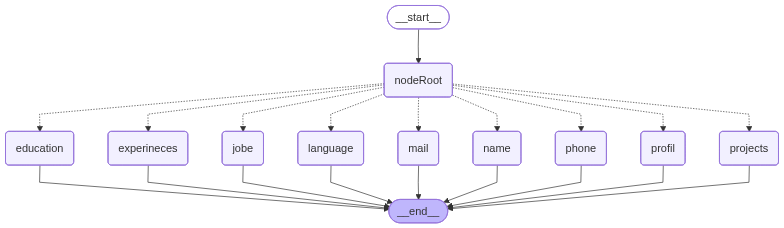

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
state={"name":""
    ,"mail":""
    ,"phone":""
    ,"jobe":""
    ,"experineces":[]
    ,"education":[]
    ,"projects":[]
    ,"profil":""
    ,"language":[]
    ,"reponce": ""
    ,"summary":""
    ,"messages": []
    ,"answer": ""}
while True:
  res=input("you :  ")
  state["reponce"]=res
  state=app.invoke(state)
  print(state["answer"].content)
  print(state)

you :  hey
node name :
Hey there, superstar! I'm so glad you're here to create an awesome CV that'll make potential employers go wild!

Before we get started, I just need to know your super cool full name. Don't worry, it's totally confidential... unless you want to share it with the world, in which case, you're already a rockstar!

So, what's your full name?
{'name': '', 'mail': '', 'phone': '', 'jobe': '', 'experineces': [], 'education': [], 'projects': [], 'profil': '', 'language': [], 'reponce': 'hey', 'summary': '', 'messages': ['User: hey', "AI: Hey there, superstar! I'm so glad you're here to create an awesome CV that'll make potential employers go wild!\n\nBefore we get started, I just need to know your super cool full name. Don't worry, it's totally confidential... unless you want to share it with the world, in which case, you're already a rockstar!\n\nSo, what's your full name?"], 'answer': AIMessage(content="Hey there, superstar! I'm so glad you're here to create an awesome 

KeyboardInterrupt: Interrupted by user

In [ ]:
print(state)

In [ ]:
#i'm ahmed ben ahmid
#AI engenering
#i love creating AI it's fun it's like magic they can learn anything and u can put them in any place to work that's why i choise AI engenering but about me i'm hard working man how love to work to achive gretness
#well not all my project are in AI but i did creat  chess ai teacher that help u learn chess by playing with u and tell how to improve and how to be better and fix ur erorr and i did a website that called ENIGhub it's form my university to help student it have 3 big futer the first one is a todo less with calender and wether widgit anf the seconde one is Ai that help u studie and the therde one is a 2d map of all the university wher u can viste ENIG  vertually and serch for class and it will guide step by step and i did build an other  web site it's for shopping online  it have client side and owner side the client he can shope and the normal stuff but he can also try the clothes with try-on ai and also have a freindly chatboot that help him shopeing like a friend with him and for the woner side i allwo the woner to add clothes and dellete and edit and alos have a dashbeard that u can  see the reveune and also he can see the order and edit it as he want so this is it all my project
#i did work in capamny solonytech is a company that creat safty in other compnay by creating AI in camira and if anything happend the company get alert and also they have a section with chatbot i did work on the chatboot i did creatied from scratich where i create a agient that have tool and Rag at the same time to make it more intelegent and i got a title as AI engenreong and it was as inerernshipe it's my first internshipe that's it
#i'm still student in oxford  i stude as resaux and telecominaction engenring and i'm on my secode years of three
#my mother languge is arabic and i can speek english and frensh fluently and i have b1 in en german
#ahemdbenahmid@gmail.com


In [ ]:
!apt-get update
!apt-get install -y texlive-latex-base texlive-latex-extra texlive-fonts-recommended texlive-fonts-extra
!apt-get install -y dvipng cm-super

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [343 B]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages 

In [ ]:
!pip install jinja2

In [ ]:
import ast
def fix_state(state):
  #experineces
  if(isinstance(state["experineces"], str)):
    projects = ast.literal_eval(state["experineces"])
    print(type(projects[0]))



    projects_json1=[]

    for l in projects:
      if isinstance(l, list):
        projects_json1.append(l[0])
      else:
        projects_json1.append(l)

    if projects_json1!=[]:
      state["experineces"]=projects_json1
    else:
      state["experineces"]=ast.literal_eval(projects)


  #job
  print(state["projects"])
  print(type(state["projects"]))
  if(isinstance(state["projects"], str)):
    projects = ast.literal_eval(state["projects"])
    print(type(projects[0]))



    projects_json1=[]

    for l in projects:
      if isinstance(l, list):
        projects_json1.append(l[0])
      else:
        projects_json1.append(l)

    if projects_json1!=[]:
      state["projects"]=projects_json1
    else:
      state["projects"]=ast.literal_eval(projects)

  #languge
  if(isinstance(state["language"], str)):
    projects = ast.literal_eval(state["language"])
    print(type(projects[0]))



    projects_json1=[]

    for l in projects:
      if isinstance(l, list):
        projects_json1.append(l[0])
      else:
        projects_json1.append(l)

    if projects_json1!=[]:
      state["language"]=projects_json1
    else:
      state["language"]=ast.literal_eval(projects)

  #education
  if(isinstance(state["education"], str)):
    projects = ast.literal_eval(state["education"])
    print(type(projects[0]))



    projects_json1=[]

    for l in projects:
      if isinstance(l, list):
        projects_json1.append(l[0])
      else:
        projects_json1.append(l)

    if projects_json1!=[]:
      state["education"]=projects_json1
    else:
      state["education"]=ast.literal_eval(projects)

fix_state(state)
print(state)

<class 'dict'>
[
  {'project': 'Chess AI Teacher', 'description': 'AI-powered chess learning platform that allows users to learn and improve their chess skills through interactive gameplay, error correction, and personalized feedback.'},
  {'project': 'ENIGhub', 'description': 'Web-based platform designed to support university students, featuring three main components: a todo list with calendar and weather widgets, an AI-assisted studying tool, and a 2D virtual map of the university campus for navigation and class searching.'},
  {'project': 'E-commerce Website', 'description': 'Online shopping platform with both client and owner sides, offering features such as try-on AI, friendly chatbot assistance, client-side shopping, and owner-side management of inventory, orders, and revenue tracking.'}
]
<class 'str'>
<class 'dict'>
<class 'dict'>
<class 'dict'>
{'name': 'Ahmed Ben Ahmid', 'mail': 'ahemdbenahmid@gmail.com', 'phone': '+216 12345678', 'jobe': 'AI Engineering', 'experineces': [{'c

In [ ]:
# Example data
#data={'name': 'Ahmed Ben Ahmid',
#      'mail': 'ahemdbenahmid@gmail.com',
#      'phone': '+216 12345678',
#      'jobe': 'AI Engineering',
#      'experineces': [{'company': 'Solonytech', 'job_title': 'AI Engineer Intern', 'description': 'Worked on a chatbot project, creating an agent with both tools and RAG capabilities to enhance its intelligence.'}]
#      , 'education': [{'university': 'ENIG', 'study': 'Resaux and Telecominaction Engenring'}],
#      'projects': [{'project': 'Chess AI Teacher', 'description': 'A chess training platform that helps users learn chess by playing with them, providing feedback on improvement and error correction.'}, {'project': 'ENIGhub', 'description': 'A university student assistance website with three main features: a todo list with calendar and weather widgets, an AI-powered study aid, and a 2D virtual map of the university for navigating and finding classes.'}, {'project': 'Online Shopping Website', 'description': 'A shopping platform with client-side and owner-side functionality, featuring try-on AI, a friendly chatbot for assistance, and a dashboard for the owner to manage orders and revenue.'}]
#      , 'profil': 'As a highly motivated and ambitious AI Engineer, I thrive on creating innovative solutions that harness the limitless potential of artificial intelligence. With a passion for harnessing the power of AI to drive progress and excellence, I leverage my technical expertise to design, develop, and deploy cutting-edge AI systems that transform industries and enhance lives. My unwavering dedication to delivering exceptional results and achieving greatness drives me to continually push the boundaries of what is possible in the field of AI Engineering.',
#      'language': [{'language': 'Arabic', 'level': 'Native'}, {'language': 'English', 'level': 'Fluent'}, {'language': 'French', 'level': 'Fluent'}, {'language': 'German', 'level': 'B1'}]}


def state_latex(data):
  # Start LaTeX document
  latex = r"""\documentclass[10pt, letterpaper]{article}

  % Packages:
  \usepackage[
      ignoreheadfoot,
      top=2 cm,
      bottom=2 cm,
      left=2 cm,
      right=2 cm,
      footskip=1.0 cm
  ]{geometry}
  \usepackage[explicit]{titlesec}
  \usepackage{tabularx}
  \usepackage{array}
  \usepackage[dvipsnames]{xcolor}
  \definecolor{primaryColor}{RGB}{0, 79, 144}
  \usepackage{enumitem}
  \usepackage{fontawesome5}
  \usepackage{amsmath}
  \usepackage[
      pdftitle={{ name }},
      pdfauthor={{ name }},
      pdfcreator={LaTeX with RenderCV},
      colorlinks=true,
      urlcolor=primaryColor
  ]{hyperref}
  \usepackage[pscoord]{eso-pic}
  \usepackage{calc}
  \usepackage{bookmark}
  \usepackage{lastpage}
  \usepackage{changepage}
  \usepackage{paracol}
  \usepackage{ifthen}
  \usepackage{needspace}
  \usepackage{iftex}

  \ifPDFTeX
      \input{glyphtounicode}
      \pdfgentounicode=1
      \usepackage[T1]{fontenc}
      \usepackage[utf8]{inputenc}
      \usepackage{lmodern}
  \fi

  \usepackage[default, type1]{sourcesanspro}

  \AtBeginEnvironment{adjustwidth}{\partopsep0pt}
  \pagestyle{empty}
  \setcounter{secnumdepth}{0}
  \setlength{\parindent}{0pt}
  \setlength{\topskip}{0pt}
  \setlength{\columnsep}{0.15cm}
  \makeatletter
  \let\ps@customFooterStyle\ps@plain
  \patchcmd{\ps@customFooterStyle}{\thepage}{
  }{}{}
  \makeatother
  \pagestyle{customFooterStyle}

  \titleformat{\section}{
      \needspace{4\baselineskip}
      \Large\color{primaryColor}
  }{
  }{
  }{
      \textbf{#1}\hspace{0.15cm}\titlerule[0.8pt]\hspace{-0.1cm}
  }[]

  \titlespacing{\section}{
      -1pt
  }{
      0.3 cm
  }{
      0.2 cm
  }

  \newenvironment{highlights}{
      \begin{itemize}[
          topsep=0.10 cm,
          parsep=0.10 cm,
          partopsep=0pt,
          itemsep=0pt,
          leftmargin=0.4 cm + 10pt
      ]
  }{
      \end{itemize}
  }

  \newenvironment{highlightsforbulletentries}{
      \begin{itemize}[
          topsep=0.10 cm,
          parsep=0.10 cm,
          partopsep=0pt,
          itemsep=0pt,
          leftmargin=10pt
      ]
  }{
      \end{itemize}
  }

  \newenvironment{onecolentry}{
      \begin{adjustwidth}{
          0.2 cm + 0.00001 cm
      }{
          0.2 cm + 0.00001 cm
      }
  }{
      \end{adjustwidth}
  }

  \newenvironment{twocolentry}[2][]{
      \onecolentry
      \def\secondColumn{#2}
      \setcolumnwidth{\fill, 4.5 cm}
      \begin{paracol}{2}
  }{
      \switchcolumn \raggedleft \secondColumn
      \end{paracol}
      \endonecolentry
  }

  \newenvironment{threecolentry}[3][]{
      \onecolentry
      \def\thirdColumn{#3}
      \setcolumnwidth{1 cm, \fill, 4.5 cm}
      \begin{paracol}{3}
      {\raggedright #2} \switchcolumn
  }{
      \switchcolumn \raggedleft \thirdColumn
      \end{paracol}
      \endonecolentry
  }

  \newenvironment{header}{
      \setlength{\topsep}{0pt}\par\kern\topsep\centering\color{primaryColor}\linespread{1.5}
  }{
      \par\kern\topsep
  }

  \newcommand{\placelastupdatedtext}{
    \AddToShipoutPictureFG*{
      \put(
          \LenToUnit{\paperwidth-2 cm-0.2 cm+0.05cm},
          \LenToUnit{\paperheight-1.0 cm}
      ){\vtop{{\null}\makebox[0pt][c]{
          \small\color{gray}\textit{}\hspace{\widthof{Last updated in September 2024}}
      }}}%
    }%
  }

  \let\hrefWithoutArrow\href
  \renewcommand{\href}[2]{\hrefWithoutArrow{#1}{\ifthenelse{\equal{#2}{}}{ }{#2 }\raisebox{.15ex}{\footnotesize \faExternalLink*}}}

  \begin{document}
  \newcommand{\AND}{\unskip
      \cleaders\copy\ANDbox\hskip\wd\ANDbox
      \ignorespaces
  }
  \newsavebox\ANDbox
  \sbox\ANDbox{}

  \placelastupdatedtext
  \begin{header}
      \fontsize{30 pt}{30 pt}
      \textbf{ """ + data["name"] + r""" }

      \vspace{0.3 cm}

      \normalsize
      \mbox{\hrefWithoutArrow{mailto:""" + data["mail"] + r"""}{{\footnotesize\faEnvelope[regular]}\hspace*{0.13cm}""" + data["mail"] + r"""}}%
      \kern 0.25 cm%
      \AND%
      \kern 0.25 cm%
      \mbox{\hrefWithoutArrow{tel:""" + data["phone"] + r"""}{{\footnotesize\faPhone*}\hspace*{0.13cm}""" + data["phone"] + r"""}}%
  \end{header}

  \vspace{0.3 cm - 0.3 cm}

  \section{Profile}
  \begin{onecolentry}
  """ + data["profil"] + r"""
  \end{onecolentry}

  \vspace{0.2 cm}

  \section{Education}
  """

  # Education
  for edu in data["education"]:
      latex += r"""
  \begin{threecolentry}{}{
  }
      \textbf{ """ + edu["university"] + r""" }
      \begin{highlights}
          \item """ + edu["study"] + r"""
      \end{highlights}
  \end{threecolentry}
  """

  # Experience
  latex += r"\section{Experience}"
  for exp in data["experineces"]:
      latex += r"""
  \begin{twocolentry}{
  }
      \textbf{ """ + exp["company"] + r""" }, """ + exp["job_title"] + r"""
      \begin{highlights}
          \item """ + exp["description"] + r"""
      \end{highlights}
  \end{twocolentry}

  \vspace{0.2 cm}
  """

  # Projects
  latex += r"\section{Projects}"
  for pro in data["projects"]:
      latex += r"""
  \begin{twocolentry}{}
      \textbf{ """ + pro["project"] + r""" }
      \begin{highlights}
          \item """ + pro["description"] + r"""
      \end{highlights}
  \end{twocolentry}

  \vspace{0.2 cm}
  """

  # Languages
  latex += r"\section{Languages}"
  for lang in data["language"]:
      latex += r"""
  \begin{onecolentry}
      \textbf{ """ + lang["language"] + r""" :} """ + lang["level"] + r"""
  \end{onecolentry}

  \vspace{0.2 cm}
  """

  latex += r"\end{document}"

  # Save LaTeX file
  with open("cv.tex", "w", encoding="utf-8") as f:
      f.write(latex)

  print("✅ cv.tex created successfully!")




In [ ]:
import subprocess

def run_latex():
    result = subprocess.run(
        ["pdflatex", "-interaction=nonstopmode", "cv.tex"],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )
    #print(result.stdout)   # LaTeX output
    #print(result.stderr)   # Errors
    return result.returncode

In [ ]:
def generate_cv(state):
  fix_state(state)
  state_latex(state)
  run_latex()


In [ ]:
generate_cv(state)

[{'project': 'Chess AI Teacher', 'description': 'AI-powered chess learning platform that allows users to learn and improve their chess skills through interactive gameplay, error correction, and personalized feedback.'}, {'project': 'ENIGhub', 'description': 'Web-based platform designed to support university students, featuring three main components: a todo list with calendar and weather widgets, an AI-assisted studying tool, and a 2D virtual map of the university campus for navigation and class searching.'}, {'project': 'E-commerce Website', 'description': 'Online shopping platform with both client and owner sides, offering features such as try-on AI, friendly chatbot assistance, client-side shopping, and owner-side management of inventory, orders, and revenue tracking.'}]
<class 'list'>
✅ cv.tex created successfully!


In [ ]:
!pdflatex -interaction=nonstopmode cv.tex

API

In [ ]:
#API

from fastapi import FastAPI
from pydantic import BaseModel
import uvicorn

app = FastAPI()



# ----------------------------
# API Models
# ----------------------------
class State(BaseModel):
    data: dict


# ----------------------------
# API Endpoint
# ----------------------------
@app.post("/generate")
def generate(state: State):
  if (state["name"]==""

  or state["jobe"]==""

  or state["profil"]==""

  or state["projects"]==[]

  or state["experineces"]==[]

  or state["education"]==[]

  or state["language"]==[]

  or state["mail"]==""

  or state["phone"]!=""):
    state["reponce"]=res
    state=app.invoke(state)
    return state

  else:
    generate_cv(state)
    return {"cv": "cv.pdf"}




# ----------------------------
# Run server
# ----------------------------
if __name__ == "__main__":
    uvicorn.run("api:app", host="0.0.0.0", port=8000, reload=True)